In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Vibrating crystal

Consider a nucleus in a one dimensional crystal, held in place by the repulsive forces from its neighbors. This force obeys Coulomb’s Law:

$$
\lvert \vec{F} \rvert = \frac{1}{4\pi\epsilon_0}\frac{q_1 q_2}{r^2}
$$

where $r$ is the distance between the two nuclei. If we assume that all the nuclei have the same charge, we can simplify the equation to:

$$
\lvert \vec{F} \rvert = \frac{\kappa}{r^2}
$$

where

$$
\kappa = \frac{q_1 q_2}{4\pi\epsilon_0}
$$

Now, consider a system with 3 nuclei (as shown in the figure below) where the two outside nuclei are held in place but the middle one can oscillate along the horizontal axis.

![3 nuclei](setup.png)

## Finding the differential equation

We can use Newton second law to find the differential equation.

$$
\begin{align}
F_{net} &= m\frac{d^2x}{dt^2} \\
&= F_{AB} + F_{CB} \\
&= \frac{\kappa}{(d+x)^2} - \frac{\kappa}{(d-x)^2}
\end{align}
$$

The equation above, we use the fact that the force of A on B pushes B in the position direction (same sign repels) and that the force of C on B pushes B in the negative direction. We can arrange the equation above into:

$$
\frac{d^2x}{dt^2} = \frac{\kappa}{m}\left( \frac{1}{(d+x)^2} - \frac{1}{(d-x)^2}\right)
$$

*This is a very hard equation to solve. We have to do it numerically.*

## Maclaurin series

But what if we restrict our analysis to when the motion of B is small: $x\approx 0$. 

We can apply the steps to find the coefficients to:

$$
f(x) = f(0) + f'(0)x + \frac{f''(0)}{2!}x^2 + \ldots
$$

Looking at each term:

$$
f(0) = \frac{\kappa}{m}\left( \frac{1}{(d+0)^2} - \frac{1}{(d-0)^2}\right) = 0
$$

$$
f'(x) = = \frac{-2\kappa}{m}\left( \frac{1}{(d+x)^3} + \frac{1}{(d-x)^3}\right)
$$

and

$$
f'(0) = \frac{-2\kappa}{m}\left( \frac{1}{(d+0)^3} + \frac{1}{(d-0)^3}\right) = \frac{-4\kappa}{md^3}
$$

We can stop here and get:

$$
\frac{d^2x}{dt^2} = \frac{-4\kappa}{md^3}x
$$

This is a much easier differential to solve. Later this semester, we will learn that the general solution for this equation is:

$$
x(t) = A\sin(\omega t) + B\cos(\omega t)
$$

with $\omega = 2\sqrt{\kappa/md^3}$.

## Comparing the full result to the Maclaurin series

We will set the initial values of the problem to $m=1$, $\kappa=1$, and $d=1$. Nucleus B starts at $x=x_0$ with zero velocity. (We will test different values of $x_0$ in our solutions.

In [15]:
x0 = 0.05

### Numerical solution

To solve the solve equation, we will use the Euler numerical method.

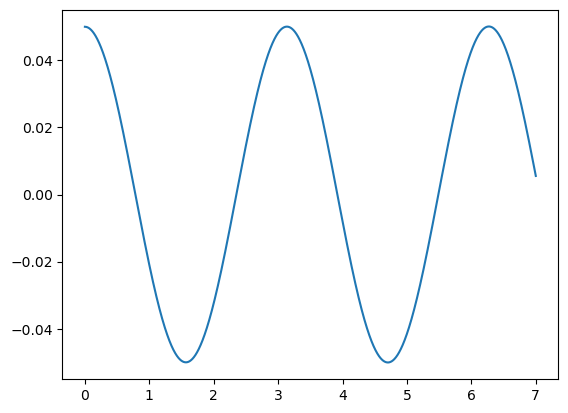

In [16]:
def acceleration(x):
    return 1/(1+x)**2 - 1/(1-x)**2

max_time = 7
num_time = 50000

time = np.linspace(0, max_time, num=num_time)
dt = time[1]-time[0]

velocity = np.zeros(num_time)
position = np.zeros(num_time)
position[0] = x0

for i in range(1,num_time):
    velocity[i] = velocity[i-1]+acceleration(position[i-1])*dt
    position[i] = position[i-1]+velocity[i-1]*dt

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.plot(time, position)

## Approximate solution

Using the initial conditions, the solution to the approximation is:

$$
x(t) = x_0 \cos(2t)
$$

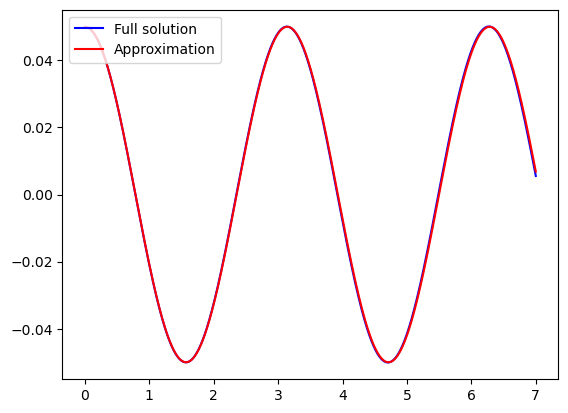

In [17]:
position_app = x0*np.cos(2*time)

fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.plot(time, position, 'b', label="Full solution")
ax1.plot(time, position_app, 'r', label="Approximation")
ax1.legend(loc='upper left')

## Trying things out

Adjust the value of $x_0$ and check when the approximation we made about the size of the displacement of B starts to break down.